Try to learn chua but with RNNs or reservoir computing methods

basically neural networks but the connections also go back or on themselves

In [3]:
import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import optax as opx
import matplotlib.pyplot as plt 
import jax.random as jr
import pysindy as ps 

jax.config.update("jax_enable_x64", True) # enable 64 float precision for stiff problems

In [4]:
# generate train and val data
ALPHA, BETA, GAMMA, A, C = (10, 16, 0, 1, -0.143)

col_dict = {
    0: 'r', 
    1: 'g',
    2: 'b'
}
var_dict = {
    0: 'x',
    1: 'y',
    2: 'z'
}

def chua_model(t, xyz, args):
    alpha, beta, gamma, a, c = args 
    x,y,z = xyz 
    return jnp.array([
        alpha*(y-a*x**3-c*x),
        x-y+z, 
        -beta*y - gamma*z
    ])



In [107]:

T_MAX = 60
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.05))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), 
                                                                max_steps=4096*2*2*2, saveat=saveat)

    x_train = sol_train.ys[::5]
    t_train = sol_train.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                                                                                              max_steps=4096*2*2*2)

    x_val = sol_val.ys[::2]
    t_val = sol_val.ts[::2]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [108]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


In [131]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [17]:
class ChuaUdeX_PEM_RecursiveFF(eqx.Module):
    # Recursive FF Variant (one paper)

    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array
    lags: int = eqx.field(static=True)

    def __init__(self, alpha, beta, gamma, K, key, lags):
        self.net = eqx.nn.MLP(
            in_size=lags,
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        self.lags = lags
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, history):
        return jnp.array(
            [-self.alpha*self.net(history), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, history, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, history) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, history, args):
        return self.physics(t, state) + self.residual(t, history)

    def __call__(self, t, state, args):
        history, obs_fun, t_obs_end = args

        return jax.lax.cond(
                t > t_obs_end,
                lambda _: self.call_normal(t, state, history, obs_fun),
                lambda _: self.call_pem(t, state, history, obs_fun),
                operand=None,
            )

In [126]:
@eqx.filter_jit
def solve_model(model, x_data, ts, obs_fun):
    lags = model.lags
    solver = dfx.Tsit5()

    init_window = x_data[:lags]   # shape (lags, 3)

    def step(window, idx):
        t0 = ts[idx]
        t1 = ts[idx + 1]

        state0 = window[-1]
        history = window[:, 0]    # lagged x-values

        sol = dfx.diffeqsolve(
            dfx.ODETerm(model),
            solver=solver,
            t0=t0,
            t1=t1,
            dt0=0.01,
            y0=state0,
            args=(history, obs_fun, ts[-1]),
            saveat=dfx.SaveAt(ts=jnp.array([t1])),
        )

        new_state = sol.ys[0]

        new_window = jnp.concatenate(
            [window[1:], new_state[None, :]],
            axis=0,
        )

        return new_window, new_state

    idxs = jnp.arange(lags - 1, len(ts) - 1)

    final_window, preds = jax.lax.scan(step, init_window, idxs)

    preds = jnp.concatenate([init_window, preds], axis=0)

    return preds

@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_model(model, y_true, ts, obs_fun)
    return jnp.linalg.norm(jnp.average((pred - y_true) ** 2, axis=1))

@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

In [127]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_val = LinearInterpolator(t_val, x_val)

ude_pem = ChuaUdeX_PEM_RecursiveFF(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key, 15)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	2.7057e-01	4.3487e-01
1	3.2330e-01	---
2	2.7155e-01	---
3	2.8128e-01	---
4	2.9515e-01	---
5	2.8471e-01	---
6	2.6996e-01	---
7	2.6570e-01	---
8	2.7064e-01	---
9	2.7518e-01	---
10	2.7393e-01	---
11	2.6838e-01	---
12	2.6274e-01	---
13	2.6000e-01	---
14	2.6017e-01	---
15	2.6096e-01	---
16	2.6010e-01	---
17	2.5687e-01	---
18	2.5231e-01	---
19	2.4829e-01	---
20	2.4604e-01	---
21	2.4526e-01	---
22	2.4454e-01	---
23	2.4280e-01	---
24	2.4075e-01	---
25	2.3980e-01	---
26	2.3954e-01	---
27	2.3831e-01	---
28	2.3546e-01	---
29	2.3268e-01	---
30	2.3112e-01	---
31	2.3001e-01	---
32	2.2797e-01	---
33	2.2518e-01	---
34	2.2236e-01	---
35	2.1937e-01	---
36	2.1538e-01	---
37	2.1097e-01	---
38	2.0669e-01	---
39	2.0152e-01	---
40	1.9600e-01	---
41	1.9050e-01	---
42	1.8467e-01	---
43	1.8016e-01	---
44	1.7602e-01	---
45	1.7083e-01	---
46	1.6738e-01	---
47	1.6509e-01	---
48	1.6144e-01	---
49	1.5773e-01	---
50	1.5379e-01	---
51	1.4994e-01	---
52	1.4701e-01	---
53	1.4332e-01	---
54	1.3968e-01	---
55	1.3683e-01

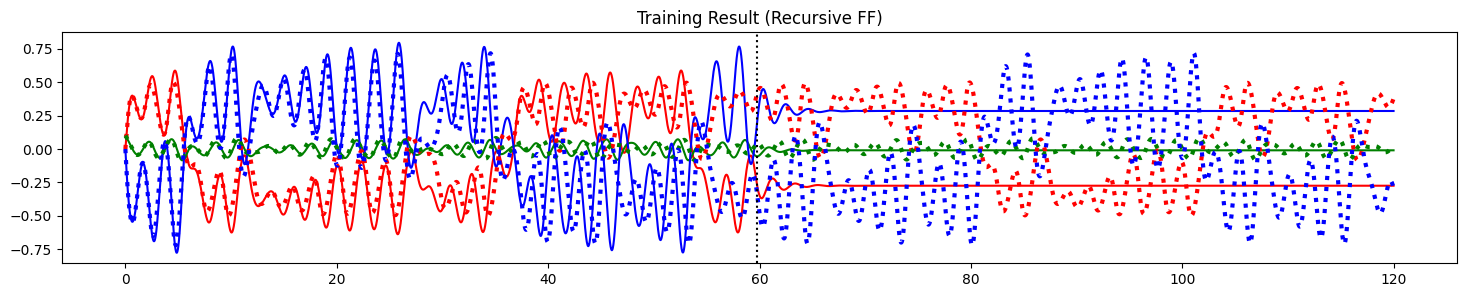

In [128]:
term = dfx.ODETerm(chua_model)

T_MAX = 120

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper)
traj_true = sol.ys

traj_final = solve_model(ude_pem, sol.ys[:15],t_eval, linear_interp)

fig, axes = plt.subplots(figsize=(18, 3))

plt.plot(t_eval, traj_final[:, 0], color='r', alpha=1)
plt.plot(t_eval, traj_final[:, 1], color='g', alpha=1)
plt.plot(t_eval, traj_final[:, 2], color='b', alpha=1)

plt.plot(t_eval, traj_true[:, 0], color='r', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 1], color='g', linestyle=':',  linewidth=3)
plt.plot(t_eval, traj_true[:, 2], color='b', linestyle=':',  linewidth=3)

plt.axvline(t_train[-1], color="k", linestyle=":", label="Last Training Set Point")

plt.title("Training Result (Recursive FF)")
plt.show()


idea: train on test sets (or a reserved part of training set) after the training is done

In [10]:
class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [18]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

In [19]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)

    def __call__(self, t, state, args):
        obs_fun = args

        return jax.lax.cond(
                t > obs_fun.t_obs[-1],
                lambda _: self.call_normal(t, state, args),
                lambda _: self.call_pem(t, state, args),
                operand=None,
            )

In [30]:

T_MAX = 750
@eqx.filter_jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.5))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.001, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), 
                                                                max_steps=4096*1000, saveat=saveat)
    
    eight_idx = int(len(sol_train.ts) * 0.8)

    x_train = sol_train.ys[:eight_idx:1]
    t_train = sol_train.ts[:eight_idx:1]

    x_test = sol_train.ys[eight_idx::1]
    t_test = sol_train.ts[eight_idx::1]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.5))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.001, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                                                                                              max_steps=4096*1000)

    x_val = sol_val.ys[::1]
    t_val = sol_val.ts[::1]

    return x_train, t_train, x_test, t_test, x_val, t_val, sol_train, sol_val

In [31]:
x_train, t_train, x_test, t_test, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


In [34]:
@eqx.filter_jit
def solve_ude_long_horizon(model, y0, ts, obs_fun):
    t0s = ts[:-1]
    t1s = ts[1:]

    def scan_body(carry_y, times):
        t_start, t_end = times 
        sol = dfx.diffeqsolve(
            dfx.ODETerm(model),
            solver = dfx.Tsit5(),
            t0 = t_start, 
            t1 = t_end,
            dt0 = 0.1,
            y0 = carry_y,
            args=obs_fun,
            saveat = dfx.SaveAt(t1 = True)
        )

        y_final = sol.ys[-1]
        return y_final, y_final
    
    final_y, all_ys = jax.lax.scan(scan_body, y0, (t0s, t1s))
    
    return jnp.concatenate([y0[jnp.newaxis, ...], all_ys], axis=0)


@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    # calculate loss
    pred = solve_ude_long_horizon(model, x0, ts, obs_fun)
    return jnp.mean((pred - y_true) ** 2)

@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [35]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	1.3011e-02	1.3105e-02
1	1.3103e-02	---
2	1.3505e-02	---
3	1.2914e-02	---
4	1.2946e-02	---
5	1.3071e-02	---
6	1.2785e-02	---
7	1.2653e-02	---
8	1.2739e-02	---
9	1.2681e-02	---
10	1.2503e-02	---
11	1.2439e-02	---
12	1.2468e-02	---
13	1.2368e-02	---
14	1.2233e-02	---
15	1.2199e-02	---
16	1.2171e-02	---
17	1.2071e-02	---
18	1.1993e-02	---
19	1.1972e-02	---
20	1.1900e-02	---
21	1.1818e-02	---
22	1.1788e-02	---
23	1.1725e-02	---
24	1.1635e-02	---
25	1.1582e-02	---
26	1.1504e-02	---
27	1.1411e-02	---
28	1.1341e-02	---
29	1.1238e-02	---
30	1.1133e-02	---
31	1.1034e-02	---
32	1.0904e-02	---
33	1.0779e-02	---
34	1.0635e-02	---
35	1.0469e-02	---
36	1.0296e-02	---
37	1.0085e-02	---
38	9.8583e-03	---
39	9.5820e-03	---
40	9.2311e-03	---
41	8.8180e-03	---
42	8.3444e-03	---
43	7.8005e-03	---
44	7.1983e-03	---
45	6.6114e-03	---
46	5.8067e-03	---
47	4.9695e-03	---
48	4.3460e-03	---
49	4.7107e-03	---
50	5.4022e-03	---
51	3.5257e-03	---
52	3.6676e-03	---
53	3.6836e-03	---
54	2.3203e-03	---
55	3.1945e-03

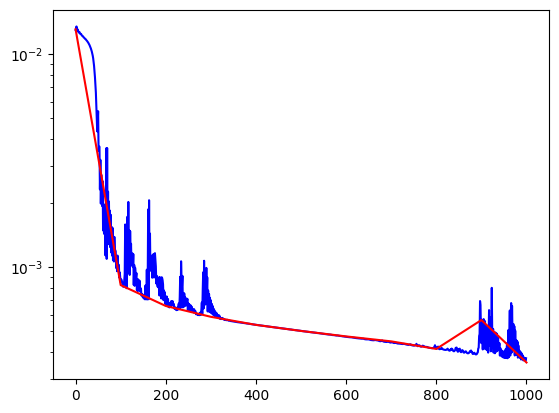

In [48]:
plt.semilogy(jnp.arange(0, 1000), train_losses_pem, color="blue")
plt.semilogy(jnp.arange(0, 11)*100, val_losses_pem, color="red")

In [38]:
eqx.tree_serialise_leaves(r"./models_weights/sth_model_eightypercent.eqx", ude_pem)


In [84]:
ude_pem = eqx.tree_deserialise_leaves("./models_weights/sth_model_eightypercent.eqx", ude_pem)

In [85]:
# train on the remaining 20% only
key = jr.PRNGKey(0)
linear_interp_test = LinearInterpolator(t_test, x_test)
linear_interp_train = LinearInterpolator(t_train, x_train)

# Train UDE PEM 

lr = 0.01
n_epochs = 300
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    # step 1: find x_test[0] by simulating the model until last step
    initial_cond = dfx.diffeqsolve(dfx.ODETerm(ude_pem), dfx.Tsit5(), t_train[0], t_train[-1], 0.01, x_train[0], saveat=dfx.SaveAt(ts=[t_train[-1]]), args=linear_interp_train,
                                   max_steps=100_000).ys[0]
    
    
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, initial_cond, x_test, t_test, optimizer, linear_interp_test)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	1.0009e-03	2.3207e-02
1	3.7737e-02	---
2	2.0192e-02	---
3	2.3450e-02	---
4	1.0547e-02	---
5	7.5672e-03	---
6	1.1182e-02	---
7	9.3773e-03	---
8	6.2138e-03	---
9	5.2365e-03	---
10	6.2808e-03	---
11	6.3565e-03	---
12	5.6528e-03	---
13	5.0019e-03	---
14	4.4327e-03	---
15	4.4045e-03	---
16	4.8563e-03	---
17	4.9900e-03	---
18	4.5759e-03	---
19	4.2094e-03	---
20	4.0726e-03	---
21	3.9790e-03	---
22	3.9547e-03	---
23	4.0080e-03	---
24	4.0195e-03	---
25	3.8664e-03	---
26	3.6696e-03	---
27	3.5734e-03	---
28	3.5688e-03	---
29	3.5899e-03	---
30	3.5515e-03	---
31	3.4716e-03	---
32	3.3681e-03	---
33	3.2512e-03	---
34	3.1584e-03	---
35	3.0962e-03	---
36	3.0379e-03	---
37	2.9562e-03	---
38	2.8570e-03	---
39	2.7824e-03	---
40	2.7087e-03	---
41	2.6172e-03	---
42	2.5235e-03	---
43	2.4116e-03	---
44	2.2874e-03	---
45	2.1564e-03	---
46	2.0165e-03	---
47	1.8990e-03	---
48	1.7347e-03	---
49	1.5861e-03	---
50	1.4290e-03	---
51	1.2946e-03	---
52	1.4070e-03	---
53	1.7080e-03	---
54	2.9859e-03	---
55	2.7656e-03

In [91]:
eqx.tree_serialise_leaves(r"./models_weights/sth_model_full.eqx", ude_pem)


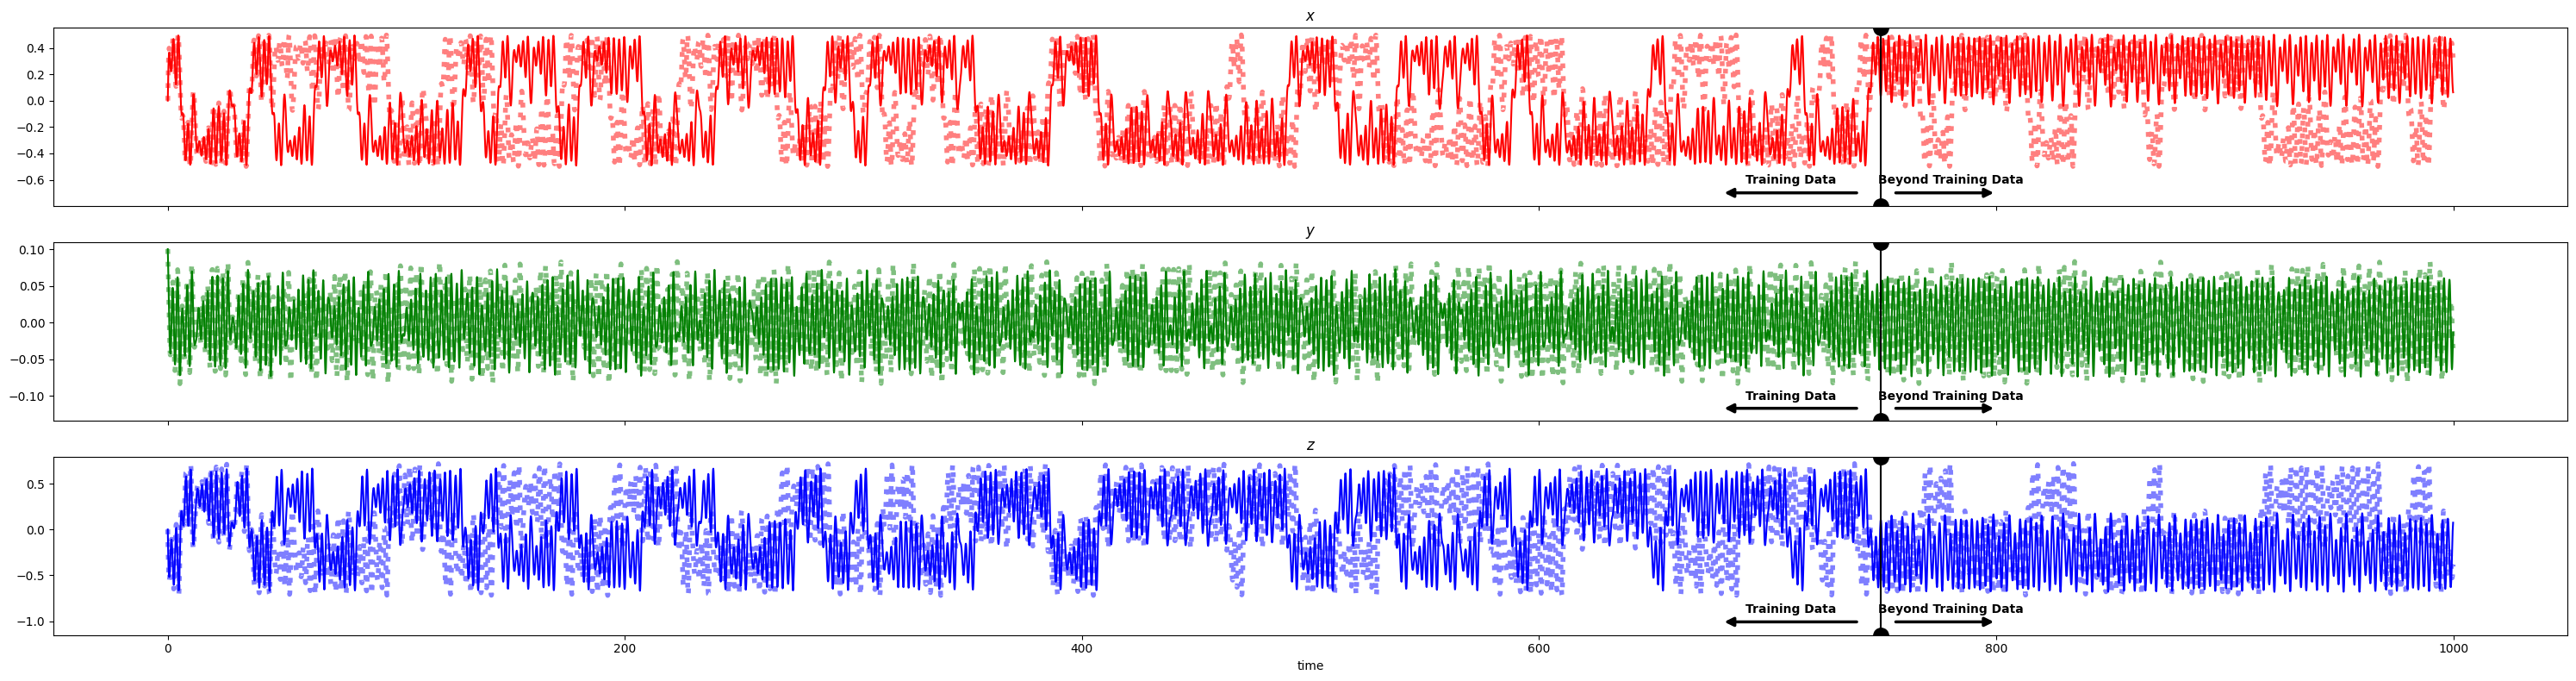

In [87]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 1000

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.1)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)
linear_interp_combined = LinearInterpolator(jnp.concatenate([t_train, t_test]), jnp.concatenate([x_train, x_test]))
# training set
fig, axes = plt.subplots(3, 1, figsize=(30, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper, 
                      max_steps=4096*2*2*2)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_combined, saveat=saveat, stepsize_controller=stepper, 
                             max_steps=4096*2*2*2*2*2*2,
                             ).ys


for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval, traj_final[:, i], color=col_dict[i],)
    plt.plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=4, alpha=0.5)
    plt.axvline(t_test[-1], color="k", label="Last Training Set Point", marker=".", markersize=25)
    plt.title(f"${var_dict[i]}$")

    y_min = min(jnp.min(traj_true[:, i]), jnp.min(traj_final[:, i]))
    plt.ylim(y_min * 1.6, None)

    plt.annotate('', xy=(800, y_min+y_min*0.4), xytext=(755, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(800+760), y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold")
# 
    plt.annotate('', xy=(740, y_min+y_min*0.4), xytext=(680, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(740+680), y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold" )

plt.xlabel("time")

plt.tight_layout()
plt.show()

In [88]:
# Seems to re-align somewhere... let's inspect closely
key = jr.PRNGKey(0)
old_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, K=[.1, .1, .1], key=key)
old_pem = eqx.tree_deserialise_leaves("./models_weights/sth_model_eightypercent.eqx", old_pem)

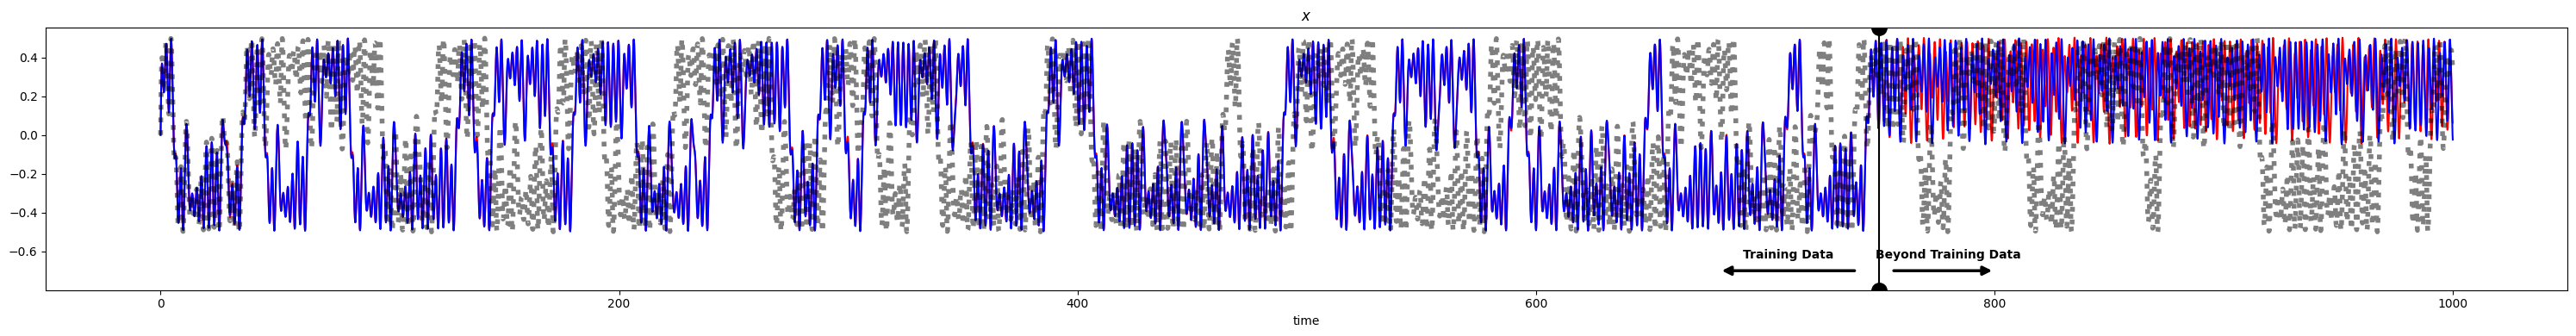

In [90]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)
term_ude_old = dfx.ODETerm(old_pem)

T_MAX = 1000

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.1)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)
linear_interp_combined = LinearInterpolator(jnp.concatenate([t_train, t_test]), jnp.concatenate([x_train, x_test]))
# training set
fig, axes = plt.subplots(1, 1, figsize=(30, 4))

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper, 
                      max_steps=4096*2*2*2)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_combined, saveat=saveat, stepsize_controller=stepper, 
                             max_steps=4096*2*2*2*2*22,
                             ).ys

traj_final_old = dfx.diffeqsolve(term_ude_old, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp_combined, saveat=saveat, stepsize_controller=stepper, 
                             max_steps=4096*2*2*2*2,
                             ).ys

for i in range(1):
    plt.plot(t_eval, traj_final[:, i], color='red')
    plt.plot(t_eval, traj_final_old[:, i], color='blue')
    plt.plot(t_eval, traj_true[:, i], color='black', linestyle=':', linewidth=4, alpha=0.5)
    plt.axvline(t_test[-1], color="k", label="Last Training Set Point", marker=".", markersize=25)
    plt.title(f"${var_dict[i]}$")

    y_min = min(jnp.min(traj_true[:, i]), jnp.min(traj_final[:, i]))
    plt.ylim(y_min * 1.6, None)

    plt.annotate('', xy=(800, y_min+y_min*0.4), xytext=(755, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(800+760), y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold")
# 
    plt.annotate('', xy=(740, y_min+y_min*0.4), xytext=(680, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(0.5*(740+680), y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold" )

plt.xlabel("time")

plt.tight_layout()
plt.show()

In [100]:
# Compare the learned networks
ys = []
ys_before = []
ys_after = []

for x in (x_space:=jnp.arange(-3, 3, 0.01)):
    ys_before.append(old_pem.net(x))
    ys_after.append(ude_pem.net(x))
    ys.append(A*x**3 + C*x)


Array(750., dtype=float64)

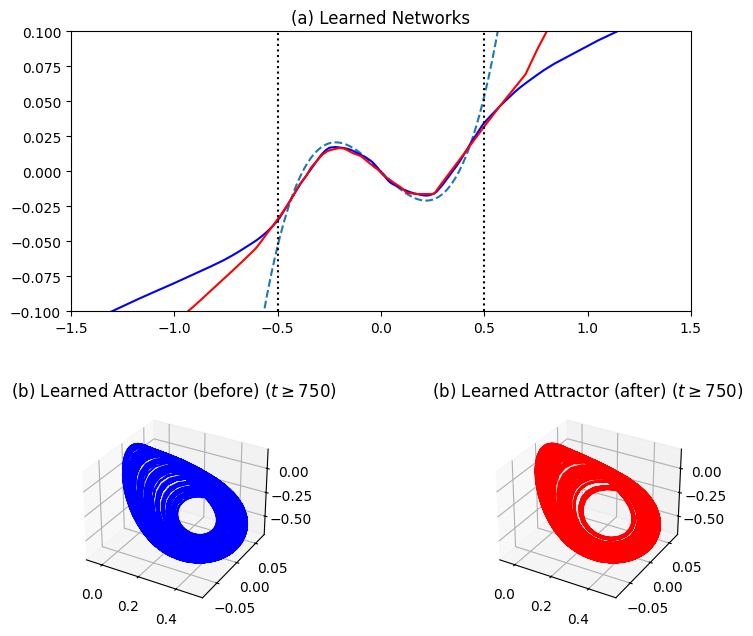

In [129]:
mosaic = [
    ['fun', 'fun'],
    ['3d_1', '3d_2']
]

fig, axes = plt.subplot_mosaic(mosaic, figsize=(8, 8),
                                per_subplot_kw={'3d_1': {'projection': '3d'}, 
                                               '3d_2': {'projection': '3d'}},
                    gridspec_kw={'height_ratios': [1,1], 'wspace':1}
)

plt.sca(axes['fun'])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, ys_before, label="Learned g(x) (before)", color='blue')
plt.plot(x_space, ys_after, label="Learned g(x) (after)", color='red' )

plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-1.5, 1.5)
plt.ylim(-0.1, 0.1)
plt.title("(a) Learned Networks")


plt.sca(axes['3d_1'])

plt.title(r"(b) Learned Attractor (before) ($t \geq 750$)")
plt.plot(traj_final_old[750*10:, 0],traj_final_old[750*10:, 1],traj_final_old[750*10:, 2],alpha=1, color='blue')
plt.sca(axes['3d_2'])
plt.title(r"(b) Learned Attractor (after) ($t \geq 750$)")
plt.plot(traj_final[750*10:, 0],traj_final[750*10:, 1],traj_final[750*10:, 2],alpha=1, color='red')


plt.show()

# Training on R^2 Loss (sort of)

Consider the R^2 loss as
$$
R^2 = 1- \frac{\text{MSE} }{\sum_t ({x^{(i)}(t)-\overline{x^{(i)}})^2}}
$$

Consider only the second part, so some sort of normalized MSE:
$$
1-R^2 = \frac{\text{MSE} }{\sum_t ({x^{(i)}(t)-\overline{x^{(i)}})^2}}
$$


In [132]:
def zero_last_layer(mlp):
    last = mlp.layers[-1]

    new_last = eqx.tree_at(
        lambda l: (l.weight, l.bias),
        last,
        (
            jnp.zeros_like(last.weight),
            jnp.zeros_like(last.bias),
        ),
    )

    mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, new_last)
    return mlp

class LinearInterpolator(eqx.Module):
    t_obs: jax.Array
    y_obs: jax.Array

    def __call__(self, t):
        t = jnp.clip(t, self.t_obs[0], self.t_obs[-1])
        idx = jnp.searchsorted(self.t_obs, t, side="left")
        idx = jnp.clip(idx, 1, self.t_obs.shape[0] - 1)

        t0, t1 = self.t_obs[idx - 1], self.t_obs[idx]
        y0, y1 = self.y_obs[idx - 1], self.y_obs[idx]
        w = (t - t0) / (t1 - t0 + 1e-12)
        return (1.0 - w) * y0 + w * y1

In [133]:
class ChuaUdeX_PEM(eqx.Module):
    net: eqx.nn.MLP
    alpha: float
    beta: float 
    gamma: float 
    K: jax.Array

    def __init__(self, alpha, beta, gamma, K, key):
        self.net = eqx.nn.MLP(
            in_size='scalar',
            out_size='scalar',
            width_size=64,
            depth=5,
            activation=jax.nn.relu,
            key=key,
        )
        
        self.alpha = alpha 
        self.beta = beta 
        self.gamma = gamma 
        self.K = jnp.asarray(K)

        # zero weight the layer
        self.net = zero_last_layer(self.net)


    def physics(self, t, state):
        # known terms
        x, y, z = state
        return jnp.array(
            [self.alpha*y, x-y+z, -self.beta*y-self.gamma*z]
        )

    def residual(self, t, state):
        x, _, _ = state
        return jnp.array(
            [-self.alpha*self.net(x), 0,0]
        )
    
    def error(self, t, state, obs_fun):
        y_hat = obs_fun(t)
        return y_hat - state

    def call_pem(self, t, state, args):
        obs_fun = args
        return self.physics(t, state) + self.residual(t, state) + self.K * self.error(t, state, obs_fun)
    
    def call_normal(self, t, state, args):
        return self.physics(t, state) + self.residual(t, state)

    def __call__(self, t, state, args):
        obs_fun = args

        return jax.lax.cond(
                t > obs_fun.t_obs[-1],
                lambda _: self.call_normal(t, state, args),
                lambda _: self.call_pem(t, state, args),
                operand=None,
            )

In [134]:

T_MAX = 60
@jax.jit
def get_training_set(ALPHA, BETA, GAMMA, A, C):
    term = dfx.ODETerm(chua_model)
    solver = dfx.Dopri5()
    y0 = jnp.array((0.0001, 0.1, 0))
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX, 0.05))

    # training set
    sol_train = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), 
                                                                max_steps=4096*2*2*2, saveat=saveat)

    x_train = sol_train.ys[::5]
    t_train = sol_train.ts[::5]

    # validation set
    saveat = dfx.SaveAt(ts=jnp.arange(0, T_MAX+T_MAX*0.5, 0.1))
    y0 = jnp.array((0.0001, 0.1, 0.1))
    sol_val = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX+T_MAX*0.5, dt0=0.1, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat,
                                                                                              max_steps=4096*2*2*2)

    x_val = sol_val.ys[::2]
    t_val = sol_val.ts[::2]

    return x_train, t_train, x_val, t_val, sol_train, sol_val

In [135]:
x_train, t_train, x_val, t_val, sol_train, sol_val = get_training_set(ALPHA, BETA, GAMMA, A, C)


In [136]:
@eqx.filter_jit
def solve_ude_long_horizon(model, y0, ts, obs_fun):
    t0s = ts[:-1]
    t1s = ts[1:]

    def scan_body(carry_y, times):
        t_start, t_end = times 
        sol = dfx.diffeqsolve(
            dfx.ODETerm(model),
            solver = dfx.Tsit5(),
            t0 = t_start, 
            t1 = t_end,
            dt0 = 0.1,
            y0 = carry_y,
            args=obs_fun,
            saveat = dfx.SaveAt(t1 = True)
        )

        y_final = sol.ys[-1]
        return y_final, y_final
    
    final_y, all_ys = jax.lax.scan(scan_body, y0, (t0s, t1s))
    
    return jnp.concatenate([y0[jnp.newaxis, ...], all_ys], axis=0)


@eqx.filter_value_and_grad
def loss_fn_pem(model, x0, y_true, ts, obs_fun):
    pred = solve_ude_long_horizon(model, x0, ts, obs_fun)

    ss_res = jnp.sum((y_true - pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)

    return ss_res / (ss_tot + 1e-8)
@eqx.filter_jit
def train_step_pem(model, opt_state, x0, x_true, ts, optimizer, obs_fun):
    # one train step on the dataset
    loss, grads = loss_fn_pem(model, x0, x_true, ts, obs_fun)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss


In [137]:
key = jr.PRNGKey(0)
linear_interp = LinearInterpolator(t_train, x_train)
linear_interp_jit = eqx.filter_jit(linear_interp)

linear_interp_val = LinearInterpolator(t_val, x_val)
linear_interp_jit_val = eqx.filter_jit(linear_interp_val)

ude_pem = ChuaUdeX_PEM(ALPHA, BETA, GAMMA, [0.9, 0.6, 0.6], key)

# Train UDE PEM 

lr = 0.001
n_epochs = 1000
optimizer = opx.adam(lr)
opt_state = optimizer.init(eqx.filter(ude_pem, eqx.is_inexact_array))

train_losses_pem = []
val_losses_pem = []

for i in range(0, n_epochs):
    ude_pem, opt_state, loss = train_step_pem(ude_pem, opt_state, x_train[0], x_train, t_train, optimizer, linear_interp)

    val_loss = None

    train_losses_pem.append(loss)

    if i % 100 == 0 or i==n_epochs-1:
        val_loss = loss_fn_pem(ude_pem, x_val[0], x_val, t_val, linear_interp_val)[0]
        val_losses_pem.append(val_loss)

    if val_loss is None:
        print(f"{i}\t{loss:.4e}\t---")

    else:
        print(f"{i}\t{loss:.4e}\t{val_loss:.4e}")


0	1.7837e-01	1.7145e-01
1	1.9675e-01	---
2	1.7725e-01	---
3	1.8499e-01	---
4	1.8653e-01	---
5	1.7931e-01	---
6	1.7481e-01	---
7	1.7628e-01	---
8	1.7867e-01	---
9	1.7751e-01	---
10	1.7436e-01	---
11	1.7212e-01	---
12	1.7170e-01	---
13	1.7216e-01	---
14	1.7203e-01	---
15	1.7069e-01	---
16	1.6879e-01	---
17	1.6747e-01	---
18	1.6737e-01	---
19	1.6743e-01	---
20	1.6592e-01	---
21	1.6410e-01	---
22	1.6334e-01	---
23	1.6312e-01	---
24	1.6230e-01	---
25	1.6099e-01	---
26	1.6009e-01	---
27	1.5965e-01	---
28	1.5892e-01	---
29	1.5764e-01	---
30	1.5661e-01	---
31	1.5608e-01	---
32	1.5529e-01	---
33	1.5410e-01	---
34	1.5325e-01	---
35	1.5253e-01	---
36	1.5128e-01	---
37	1.5007e-01	---
38	1.4911e-01	---
39	1.4778e-01	---
40	1.4620e-01	---
41	1.4478e-01	---
42	1.4307e-01	---
43	1.4099e-01	---
44	1.3893e-01	---
45	1.3639e-01	---
46	1.3338e-01	---
47	1.3013e-01	---
48	1.2604e-01	---
49	1.2138e-01	---
50	1.1576e-01	---
51	1.0912e-01	---
52	1.0159e-01	---
53	9.2944e-02	---
54	8.2754e-02	---
55	7.0862e-02

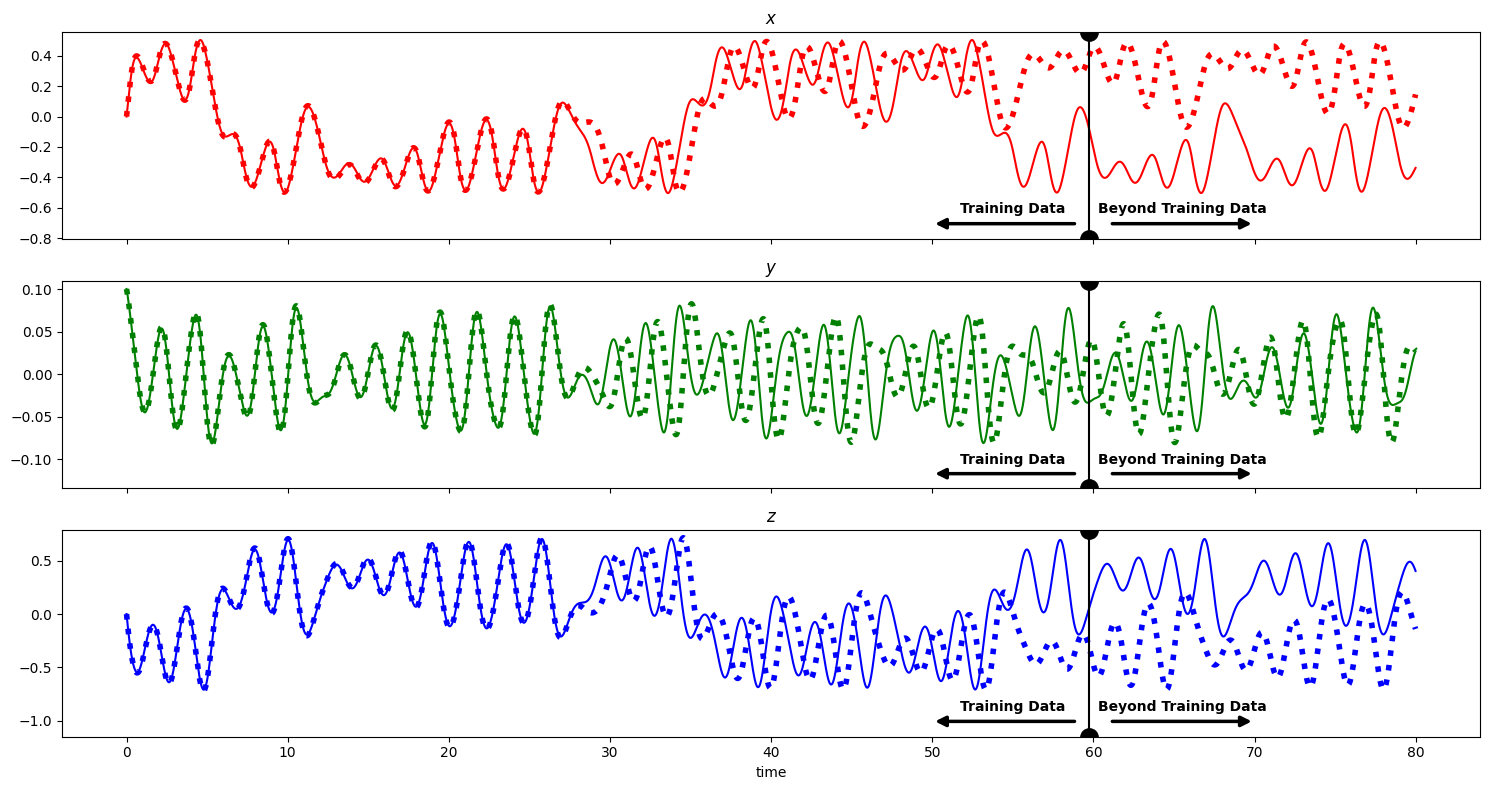

In [138]:
term = dfx.ODETerm(chua_model)
term_ude = dfx.ODETerm(ude_pem)

T_MAX = 80

solver = dfx.Tsit5()
y0 = x_train[0]
t_eval = jnp.arange(0, T_MAX, 0.01)
saveat = dfx.SaveAt(ts=t_eval)
stepper = dfx.PIDController(rtol=1e-7, atol=1e-9)

# training set
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

sol = dfx.diffeqsolve(term, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=(ALPHA, BETA, GAMMA, A, C), saveat=saveat, stepsize_controller=stepper, max_steps=10000*10*10)
traj_true = sol.ys

traj_final = dfx.diffeqsolve(term_ude, solver, t0=0, t1=T_MAX, dt0=0.01, y0=y0, args=linear_interp, saveat=saveat, stepsize_controller=stepper, max_steps=10000*10*10).ys


for i in range(3):
    plt.sca(axes[i])
    plt.plot(t_eval, traj_final[:, i], color=col_dict[i],)
    plt.plot(t_eval, traj_true[:, i], color=col_dict[i], linestyle=':', linewidth=4)
    plt.axvline(t_train[-1], color="k", label="Last Training Set Point", marker=".", markersize=25)
    plt.title(f"${var_dict[i]}$")

    y_min = min(jnp.min(traj_true[:, i]), jnp.min(traj_final[:, i]))
    plt.ylim(y_min * 1.6, None)
    
    plt.annotate('', xy=(70, y_min+y_min*0.4), xytext=(61, y_min+y_min*.4), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, mutation_scale=15))
    plt.text(65.5, y_min+y_min*0.3, r"Beyond Training Data", ha="center", va="bottom", weight="bold")

    plt.annotate('', xy=(59, y_min+y_min*0.4), xytext=(50, y_min+y_min*.4), arrowprops=dict(arrowstyle="<|-", color='k', lw=2.5, mutation_scale=15))
    plt.text(55, y_min+y_min*0.3, r"Training Data", ha="center", va="bottom", weight="bold" )

plt.xlabel("time")

plt.tight_layout()
plt.show()

In [139]:
# plot learned network
y_hats = []
ys = []
for x in (x_space:=jnp.arange(-1, 1, 0.01)):
    y_hat = ude_pem.net(x)
    y_hats.append(y_hat)
    ys.append(A*x**3 + C*x)


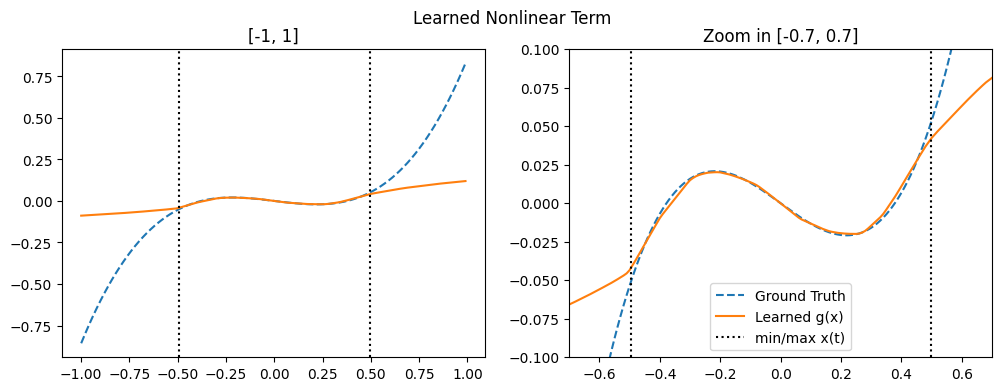

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plt.sca(axes[0])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.title("[-1, 1]")

plt.sca(axes[1])
plt.plot(x_space, ys, label="Ground Truth", linestyle="--")
plt.plot(x_space, y_hats, label="Learned g(x)")
plt.axvline(x_train[:, 0].min(), color="k", linestyle=":")
plt.axvline(x_train[:, 0].max(), color="k", linestyle=":", label="min/max x(t)")
plt.xlim(-0.7, 0.7)
plt.ylim(-0.1, 0.1)
plt.title("Zoom in [-0.7, 0.7]")

plt.legend()
plt.suptitle("Learned Nonlinear Term")

plt.show()